### IMPORTACION DE LIBRERIAS Y CARGA DE DATOS

In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [ ]:
# Tratamiento de Datos
import pandas as pd
import numpy as np
from IPython.display import display

# Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Para que se muestren todas las columnas al inspeccionar los DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)

In [ ]:
from framework import sp_carga_exploracion as sc
from framework import sp_limpieza_transformacion as sl
from framework import sp_eda as se
from framework import sp_abtest as sb
from framework import sp_modelado as sm

In [ ]:
from sklearn.linear_model import (
    LinearRegression, 
    LogisticRegression, 
    Ridge, 
    Lasso, 
    ElasticNet)



#### CARGA DATASET ORIGINAL

In [ ]:
df_o = sc.leer_csv('../data/raw/dataset_estudiantes.csv')

CSV CARGADO
Archivo: ../data/raw/dataset_estudiantes.csv
Filas:   1000
Columnas: 11


#### CARGA DATASET DATOS LIMPIOS

In [ ]:
df_e = sc.leer_csv('../data/processed/02_datos_limpios.csv')

CSV CARGADO
Archivo: ../data/processed/02_datos_limpios.csv
Filas:   1000
Columnas: 12


#### CARGA DE ARCHIVOS PKL

In [ ]:
import joblib

datos = joblib.load('../data/processed/datos_preprocesados.pkl')

X_train_reg = datos['X_train_reg']
X_test_reg = datos['X_test_reg']
y_train_reg = datos['y_train_reg']
y_test_reg = datos['y_test_reg']

In [ ]:
print(X_train_reg.dtypes)

horas_estudio_semanal                   float64
nota_anterior                           float64
tasa_asistencia                         float64
horas_sueno                             float64
edad                                    float64
tiene_tutor_ml                            int64
nivel_dificultad_facil                     bool
nivel_dificultad_medio                     bool
horario_estudio_preferido_noche            bool
horario_estudio_preferido_tarde            bool
estilo_aprendizaje_kinestesico             bool
estilo_aprendizaje_lectura_escritura       bool
estilo_aprendizaje_visual                  bool
dtype: object


### LinearRegression

¿Qué es una regresión lineal, en una frase?

Busca la combinación de pesos (coeficientes) que, multiplicados por cada una de tus 13 columnas y sumados, se acerquen lo más posible a nota_final real. Por ejemplo, algo del estilo: nota_final ≈ 2.3·horas_estudio + 1.8·nota_anterior + 0.5·tasa_asistencia + ... + constante.

Paso 1: crear el modelo y entrenarlo con `entrenar_evaluar_regresion()`

Esta única función hace dos cosas por dentro: modelo.fit(X_train, y_train) (aprende los pesos a partir de los 800 casos de entrenamiento) y luego modelo.predict(X_test) (predice sobre los 200 que el modelo nunca vio), comparando esas predicciones contra los valores reales con metricas_regresion().

In [ ]:
from sklearn.linear_model import LinearRegression

modelo_reg = LinearRegression()

resultados_reg = sm.entrenar_evaluar_regresion(modelo_reg, X_train_reg, X_test_reg, y_train_reg, y_test_reg)
print(resultados_reg)

{'MAE': 5.816520200371805, 'MSE': 52.251030163902286, 'RMSE': np.float64(7.228487404976389), 'R2': 0.36123057055860464}


Qué significa cada métrica que vas a ver, antes de que las leas
- MAE (error absoluto medio): de media, en cuántos puntos se equivoca el modelo — el más fácil de interpretar ("nos equivocamos X puntos de media").
- MSE: parecido, pero elevando al cuadrado el error — penaliza más los errores grandes, se usa sobre todo como paso intermedio.
- RMSE: la raíz de MSE, vuelve a estar en la misma escala que la nota (0-100), útil para comparar directamente con MAE.
- R²: de 0 a 1 (puede salir negativo si el modelo es malo de verdad) — qué % de la variabilidad de nota_final consigue explicar el modelo. Cercano a 1 = muy bueno.

Lectura de las métricas
- MAE = 5,82 → de media, el modelo se equivoca en unos 5,8 puntos sobre 100 al predecir la nota. No está mal para un primer modelo, pero tampoco es una precisión asombrosa.
- RMSE = 7,23 → algo más alto que el MAE (siempre pasa, porque penaliza más los errores grandes) — indica que hay algún caso donde el modelo se equivoca bastante más que la media.
- R² = 0,361 → este es el número que más llama la atención. El modelo solo explica el 36% de la variabilidad de la nota final. El 64% restante queda sin explicar por las variables que tienes.
¿Es un mal resultado? No necesariamente — y aquí viene el porqué

Recuerda el ranking de correlación que sacamos en el EDA: la variable más fuerte (horas_estudio_semanal) tenía una correlación de 0,514 con nota_final. Al cuadrado, eso solo explicaría por sí sola un ~26% de la varianza. Un R² de 0,36 con todas las variables juntas está en línea con lo que ya sabíamos: ninguna variable individual era extremadamente fuerte, así que era esperable que el modelo conjunto tampoco lo fuera.

La pregunta importante que hay que hacerse ahora

Con estas cifras, la interpretación correcta no es "el modelo es malo", es: "hay una parte sustancial de lo que determina la nota final que no está capturada en estas 8 variables" — cosas como motivación real del día del examen, dificultad específica de las preguntas, salud, circunstancias personales... factores que el dataset simplemente no recoge. Esto es un límite del dato disponible, no necesariamente un fallo del modelo o de tu proceso hasta aquí.

*Antes de sacar conclusiones definitivas, hay un paso que falta: comprobar overfitting/underfitting*

comparar_train_test() te va a decir si el R² de 0,36 es consistente entre train y test, o si el modelo está memorizando el train y generalizando peor de lo que parece:

In [ ]:
sm.comparar_train_test(modelo_reg, X_train_reg, X_test_reg, y_train_reg, y_test_reg, tipo='regresion')

R² Train: 0.3897
R² Test : 0.3612


R² Train: 0.3897 R² Test : 0.3612

Muy buena noticia, y es justo lo que quieres ver: 0,390 en train vs 0,361 en test — están muy cerca el uno del otro (diferencia de solo 0,03).

Qué significa esto
Si train fuera mucho más alto que test (por ejemplo, 0,80 en train y 0,36 en test) → sería señal de overfitting: el modelo memoriza los 800 casos de entrenamiento, pero no generaliza bien a datos nuevos.
Lo que tienes tú (train y test casi iguales) → el modelo generaliza bien. El 0,36 de R² no es un problema de "el modelo aprendió mal tus datos de entrenamiento", es un límite real de cuánto se puede explicar con estas variables, consistente tanto en los datos que vio como en los que no vio.
Conclusión honesta sobre este primer modelo
Es un resultado modesto pero fiable — no es un modelo espectacular, pero tampoco está mintiendo ni memorizando. Es exactamente lo que cabía esperar dado lo que viste en el EDA: variables con correlaciones moderadas (0,3-0,5), ninguna extremadamente fuerte, y un componente de "azar/factores no medidos" que ronda el 60% de lo que determina la nota final.

Para el informe

**Modelo de regresión — LinearRegression**

MAE=5.82, RMSE=7.23, R²=0.361 (test), R²=0.390 (train).

La cercanía entre R² train y test (diferencia de 0,03) confirma que
el modelo NO sobreajusta — generaliza de forma consistente. El R²
moderado (36%) es coherente con las correlaciones observadas en el
EDA (máximo 0,51 para una única variable): el rendimiento académico
depende en gran medida de factores no capturados en este dataset.

---------------------------------------------------------------------------------------

Vamos a realizar una comparacion de los modelos

In [ ]:
modelos = {'Linear': LinearRegression(), 'Ridge': Ridge(alpha=1.0), 'Lasso': Lasso(alpha=0.1),"ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5)}
sm.comparar_modelos(modelos, X_train_reg, X_test_reg, y_train_reg, y_test_reg, tipo='regresion')

,R2_train,R2_test,MAE_test,RMSE_test
Linear,0.3897,0.3612,5.8165,7.2285
Ridge,0.3897,0.3615,5.8173,7.2272
Lasso,0.3840,0.3649,5.8616,7.2078
ElasticNet,0.3850,0.3661,5.8575,7.2007


Un paso más antes de cerrar la regresión: importancia_variables(), para ver qué está pesando más dentro de ese 36% que sí consigue explicar — y de paso confirmar (o no) las hipótesis del EDA con los coeficientes reales del modelo:

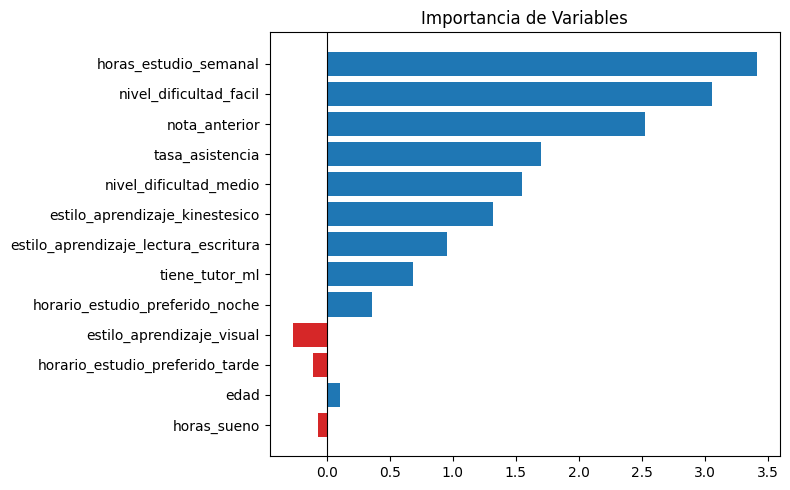

,variable,importancia
0,horas_estudio_semanal,3.415045
6,nivel_dificultad_facil,3.060894
1,nota_anterior,2.524346
2,tasa_asistencia,1.705617
7,nivel_dificultad_medio,1.553436
10,estilo_aprendizaje_kinestesico,1.318762
11,estilo_aprendizaje_lectura_escritura,0.956548
5,tiene_tutor_ml,0.683103
8,horario_estudio_preferido_noche,0.362057
12,estilo_aprendizaje_visual,-0.267531


In [ ]:
sm.importancia_variables(modelo_reg, X_train_reg.columns)

Muy buen resultado — confirma la mayoría de lo que ya sabías del EDA, con un dato nuevo interesante que solo el modelo (no la correlación simple) te podía dar.

✅ Confirma exactamente lo esperado

horas_estudio_semanal  = 3,42   <- el más fuerte, como en la correlación<br>
nota_anterior          = 2,52   <- el segundo, como en la correlación<br>
tasa_asistencia        = 1,71   <- el tercero, como en la correlación<br>

🌟 El hallazgo nuevo que solo aparece con el modelo, no con la correlación simple

nivel_dificultad_facil  = 3,06   <- casi tan fuerte como horas_estudio_semanal!<br>
nivel_dificultad_medio  = 1,55

Recuerda: dificil es la categoría de referencia (quedó fuera del One-Hot). Estos coeficientes positivos tan grandes dicen: "comparado con dificil, ser facil suma +3,06 puntos, y ser medio suma +1,55 puntos" — confirma con mucha más fuerza de la que esperábamos el hallazgo del Tukey (que dificil se separaba del resto). Y fíjate que sí se ve algo del gradiente aquí (facil > medio > 0 de dificil), aunque en el EDA univariante la diferencia entre facil y medio no fuera estadísticamente significativa por sí sola — combinado con el resto de variables, el modelo sí capta más matiz.

✅ Confirma el hallazgo débil de estilo_aprendizaje que dejamos "no concluyente"

estilo_aprendizaje_kinestesico      =  1,32<br>
estilo_aprendizaje_lectura_escritura = 0,96<br>
estilo_aprendizaje_visual           = -0,27  <- el único negativo de los 3, coherente con lo que viste en el EDA

visual sigue siendo el peor de los 4 (recuerda que auditivo es la referencia, así que negativo significa "peor que auditivo"), coherente con la señal débil que ya viste en el Tukey.

Confirmado — sin apenas peso - Prácticamente cero, tal como predecía la correlación.

edad            0,10 <br>
horas_sueno    -0,07

Para el informe

**Importancia de variables — LinearRegression**

Confirma el ranking del EDA: horas_estudio_semanal (3,42), 
nota_anterior (2,52) y tasa_asistencia (1,71) son las 3 variables 
más influyentes.

nivel_dificultad_facil (3,06) emerge como una de las variables más
fuertes del modelo, superando incluso a nota_anterior — reflejando
con más contundencia el hallazgo ya visto en el EDA (Tukey) de que
la categoría "dificil" se separa claramente del resto.

edad y horas_sueno confirman su irrelevancia (coeficientes cercanos
a 0).

`**entrenar_final()**` 

necesita el X en el mismo formato numérico final que usaste para entrenar el modelo original (13 columnas, todas numéricas, con el One-Hot y el escalado ya aplicados) — igual que X_train_reg/X_test_reg, no el X_reg original de 9 columnas con texto.

En vez de rehacer todo el pipeline de preprocesamiento desde cero, lo más simple es juntar X_train_reg y X_test_reg (que ya pasaron por encoding+escalado) en un único DataFrame con el 100% de los datos. 

X_train_reg/X_test_reg son las únicas piezas que sí guardaste en el .pkl ya con todo el proceso aplicado (encoding + escalado) — por eso juntarlas de nuevo con concat te da el X completo y correcto,

In [ ]:
X_reg_completo = pd.concat([X_train_reg, X_test_reg])
y_reg_completo = pd.concat([y_train_reg, y_test_reg])

In [ ]:
print(X_reg_completo.shape)
print(y_reg_completo.shape)

(1000, 13)
(1000,)


In [ ]:
modelo_final = sm.entrenar_final(LinearRegression(), X_reg_completo, y_reg_completo)

In [ ]:
sm.guardar_modelo(modelo_final, '../src/modelo_regresion_final.pkl')

**`simular_variable()` **

In [ ]:
resultado = sm.simular_variable(modelo_reg, X_reg_completo, 'horas_estudio_semanal', [1, 5, 10, 15, 20, 25])
print(resultado)

AttributeError: module 'framework.sp_modelado' has no attribute 'simular_variable'